<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_04_Data_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 04 — Data Quality Analysis

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 04 is to examine the quality and reliability of the
selected Student Performance dataset before machine learning development.

Data quality analysis is important because missing values, duplicate records,
invalid values and unexpected categories can affect preprocessing and model
performance.

### Today's Work

- Load the dataset independently.
- Inspect the dataset structure.
- Check missing values.
- Check duplicate records.
- Check data types.
- Check unique and unexpected values.
- Examine numerical feature ranges.
- Identify possible outliers.
- Check categorical consistency.
- Verify the project target variable.
- Prepare a data-quality summary.

No machine learning model will be trained today.

In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the UCI Student Performance dataset

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

print("Dataset loaded successfully.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully.
Features shape: (649, 30)
Target shape: (649, 3)


In [3]:
# Create the working DataFrame

df = X.copy()

df["G3"] = y["G3"]

print("Working DataFrame created.")
print("Shape:", df.shape)

df.head()

Working DataFrame created.
Shape: (649, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


In [4]:
# Create project-defined performance categories

def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(performance_category)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [5]:
# Display basic dataset information

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows: 649
Columns: 32

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3', 'performance_category']


In [6]:
# Check missing values in every column

missing_values = df.isnull().sum()

print(missing_values)

school                  0
sex                     0
age                     0
address                 0
famsize                 0
Pstatus                 0
Medu                    0
Fedu                    0
Mjob                    0
Fjob                    0
reason                  0
guardian                0
traveltime              0
studytime               0
failures                0
schoolsup               0
famsup                  0
paid                    0
activities              0
nursery                 0
higher                  0
internet                0
romantic                0
famrel                  0
freetime                0
goout                   0
Dalc                    0
Walc                    0
health                  0
absences                0
G3                      0
performance_category    0
dtype: int64


In [7]:
# Create missing-value summary

missing_summary = pd.DataFrame({
    "Missing_Values": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Values",
    ascending=False
)

missing_summary

,Missing_Values,Missing_Percentage
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


In [8]:
# Visualize missing values

missing_plot = missing_summary[
    missing_summary["Missing_Values"] > 0
]

if len(missing_plot) == 0:
    print("No missing values found in the dataset.")
else:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing_Values"]
    )

    plt.title("Missing Values by Feature")
    plt.xlabel("Feature")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=90)

    plt.show()

No missing values found in the dataset.


In [9]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
# Calculate duplicate percentage

duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(
    "Duplicate percentage:",
    round(duplicate_percentage, 2),
    "%"
)

Duplicate percentage: 0.0 %


In [11]:
# Display duplicate records if they exist

duplicates = df[df.duplicated(keep=False)]

if duplicates.empty:
    print("No duplicate records found.")
else:
    print("Duplicate records:")
    display(duplicates)

No duplicate records found.


In [12]:
# Check data types

dtype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

dtype_summary

,Feature,Data_Type
0,school,object
1,sex,object
2,age,int64
3,address,object
4,famsize,object
5,Pstatus,object
6,Medu,int64
7,Fedu,int64
8,Mjob,object
9,Fjob,object


In [13]:
print("Data type counts:")
print(df.dtypes.value_counts())

Data type counts:
object    18
int64     14
Name: count, dtype: int64


In [14]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']


In [15]:
# Examine numerical feature ranges

numerical_summary = pd.DataFrame({
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max(),
    "Mean": df[numerical_columns].mean().round(2),
    "Median": df[numerical_columns].median(),
    "Unique_Values": df[numerical_columns].nunique()
})

numerical_summary

,Minimum,Maximum,Mean,Median,Unique_Values
age,15,22,16.74,17.0,8
Medu,0,4,2.51,2.0,5
Fedu,0,4,2.31,2.0,5
traveltime,1,4,1.57,1.0,4
studytime,1,4,1.93,2.0,4
failures,0,3,0.22,0.0,4
famrel,1,5,3.93,4.0,5
freetime,1,5,3.18,3.0,5
goout,1,5,3.18,3.0,5
Dalc,1,5,1.50,1.0,5


In [16]:
# Check important numerical variables

range_checks = {
    "age": (df["age"].min(), df["age"].max()),
    "studytime": (df["studytime"].min(), df["studytime"].max()),
    "failures": (df["failures"].min(), df["failures"].max()),
    "absences": (df["absences"].min(), df["absences"].max()),
    "G3": (df["G3"].min(), df["G3"].max())
}

for feature, values in range_checks.items():
    print(
        f"{feature}: minimum = {values[0]}, maximum = {values[1]}"
    )

age: minimum = 15, maximum = 22
studytime: minimum = 1, maximum = 4
failures: minimum = 0, maximum = 3
absences: minimum = 0, maximum = 32
G3: minimum = 0, maximum = 19


In [17]:
# Identify categorical columns

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'performance_category']


In [18]:
# Analyze frequency distribution of categorical variables

for column in categorical_columns:
    print("\n" + "=" * 60)
    print("Feature:", column)

    print(
        df[column]
        .value_counts(dropna=False)
    )


Feature: school
school
GP    423
MS    226
Name: count, dtype: int64

Feature: sex
sex
F    383
M    266
Name: count, dtype: int64

Feature: address
address
U    452
R    197
Name: count, dtype: int64

Feature: famsize
famsize
GT3    457
LE3    192
Name: count, dtype: int64

Feature: Pstatus
Pstatus
T    569
A     80
Name: count, dtype: int64

Feature: Mjob
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64

Feature: Fjob
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64

Feature: reason
reason
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64

Feature: guardian
guardian
mother    455
father    153
other      41
Name: count, dtype: int64

Feature: schoolsup
schoolsup
no     581
yes     68
Name: count, dtype: int64

Feature: famsup
famsup
yes    398
no     251
Name: count, dtype: int64

Feature: paid
paid
no     610
yes

In [19]:
# Check for leading or trailing whitespace in categorical values

whitespace_issues = {}

for column in categorical_columns:
    values = df[column].dropna().astype(str)

    count = (
        values.str.strip() != values
    ).sum()

    whitespace_issues[column] = count

whitespace_summary = pd.Series(
    whitespace_issues,
    name="Whitespace_Issues"
)

whitespace_summary

,Whitespace_Issues
school,0
sex,0
address,0
famsize,0
Pstatus,0
Mjob,0
Fjob,0
reason,0
guardian,0
schoolsup,0


In [20]:
# Analyze target variable G3

print("Target variable: G3")

print("Minimum:", df["G3"].min())
print("Maximum:", df["G3"].max())
print("Mean:", round(df["G3"].mean(), 2))
print("Median:", df["G3"].median())

print("\nTarget value counts:")
print(df["G3"].value_counts().sort_index())

Target variable: G3
Minimum: 0
Maximum: 19
Mean: 11.91
Median: 12.0

Target value counts:
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


In [21]:
# Verify that performance categories correctly correspond to G3

category_check = pd.crosstab(
    df["G3"],
    df["performance_category"]
)

category_check

performance_category,High,Low,Medium
G3,,,
0,0,15,0
1,0,1,0
5,0,1,0
6,0,3,0
7,0,10,0
8,0,35,0
9,0,35,0
10,0,0,97
11,0,0,104


In [22]:
# Verify the project-defined classification rules

invalid_categories = df[
    (
        (df["G3"] < 10) &
        (df["performance_category"] != "Low")
    )
    |
    (
        (df["G3"] >= 10) &
        (df["G3"] < 15) &
        (df["performance_category"] != "Medium")
    )
    |
    (
        (df["G3"] >= 15) &
        (df["performance_category"] != "High")
    )
]

print(
    "Number of incorrectly assigned performance categories:",
    len(invalid_categories)
)

Number of incorrectly assigned performance categories: 0


In [23]:
# Identify potential outliers using the IQR method

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Potential_Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,age,16.0,18.0,2.0,13.0,21.0,1
1,Medu,2.0,4.0,2.0,-1.0,7.0,0
2,Fedu,1.0,3.0,2.0,-2.0,6.0,0
3,traveltime,1.0,2.0,1.0,-0.5,3.5,16
4,studytime,1.0,2.0,1.0,-0.5,3.5,35
5,failures,0.0,0.0,0.0,0.0,0.0,100
6,famrel,4.0,5.0,1.0,2.5,6.5,51
7,freetime,3.0,4.0,1.0,1.5,5.5,45
8,goout,2.0,4.0,2.0,-1.0,7.0,0
9,Dalc,1.0,2.0,1.0,-0.5,3.5,34


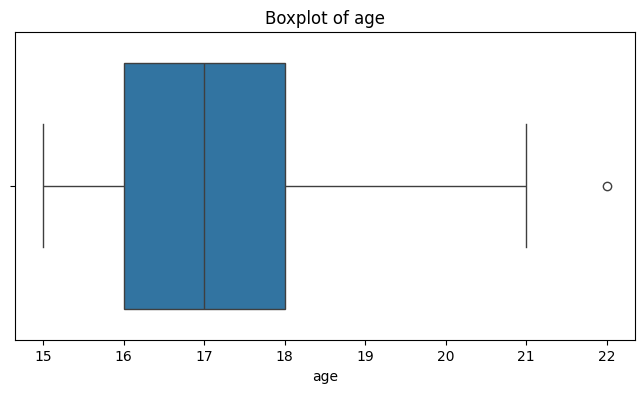

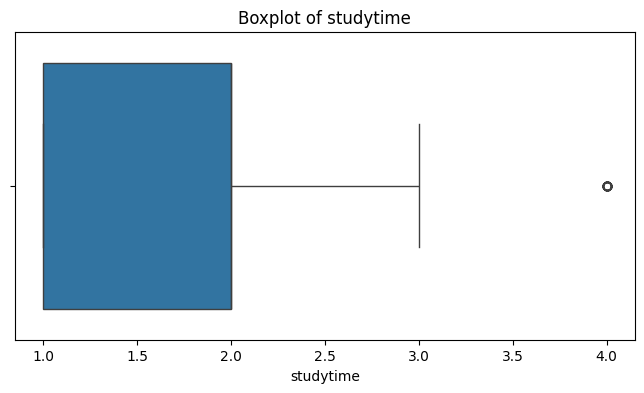

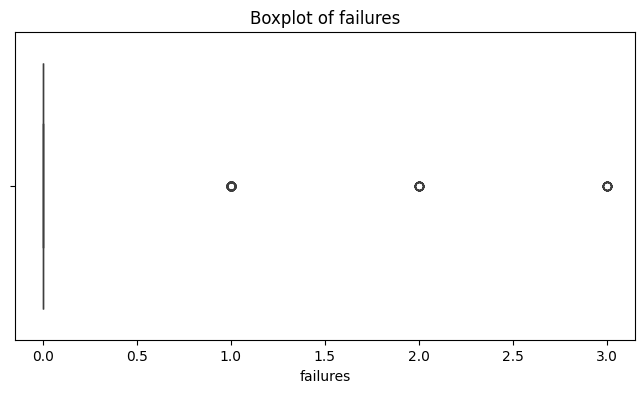

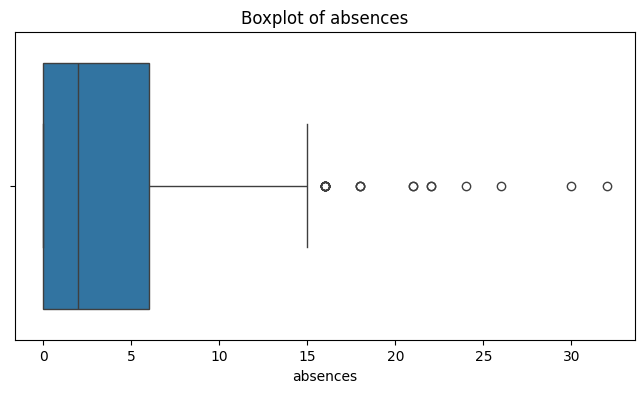

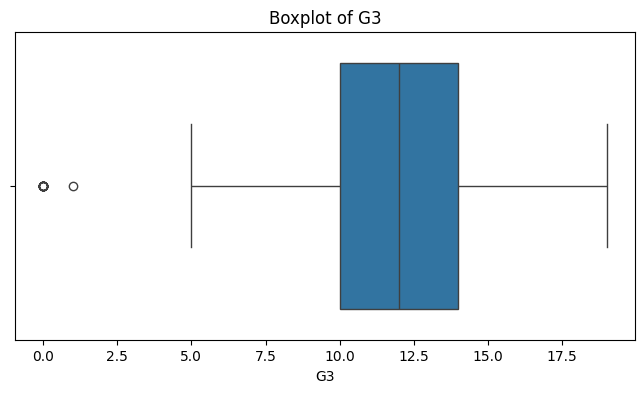

In [24]:
# Visualize distributions of important numerical variables

important_numeric = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G3"
]

for column in important_numeric:
    plt.figure(figsize=(8, 4))

    sns.boxplot(data=df, x=column)

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [25]:
# Create an overall data-quality summary

data_quality_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Unique_Values": df.nunique().values,
    "Duplicate_Values": [
        df[column].duplicated().sum()
        for column in df.columns
    ]
})

data_quality_summary

,Feature,Data_Type,Missing_Values,Unique_Values,Duplicate_Values
0,school,object,0,2,647
1,sex,object,0,2,647
2,age,int64,0,8,641
3,address,object,0,2,647
4,famsize,object,0,2,647
5,Pstatus,object,0,2,647
6,Medu,int64,0,5,644
7,Fedu,int64,0,5,644
8,Mjob,object,0,5,644
9,Fjob,object,0,5,644


In [26]:
# Final dataset quality check

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Total columns:", len(df.columns))
print("Total rows:", len(df))

print("\nData quality analysis completed successfully.")

Dataset shape: (649, 32)
Total missing values: 0
Total duplicate rows: 0
Total columns: 32
Total rows: 649

Data quality analysis completed successfully.


# Day 04 — Data Quality Findings

## Missing Values

The dataset was checked for missing values across all features.

The missing-value analysis was performed before any data-cleaning operation
so that the original quality of the dataset could be understood.

## Duplicate Records

The dataset was checked for completely duplicated rows. Duplicate records,
if present, were identified but were not automatically removed during this
analysis stage.

## Data Types

The dataset contains both numerical and categorical features. Data types
were verified to identify variables that may require different preprocessing
methods during later stages.

## Value Range Analysis

Important numerical features such as `age`, `studytime`, `failures`,
`absences` and `G3` were examined for their minimum, maximum, mean and
median values.

## Categorical Consistency

Categorical features were inspected for their unique values and frequency
distributions. This helps identify unexpected categories or inconsistent
text values before preprocessing.

## Outlier Analysis

The Interquartile Range (IQR) method was used to identify potential outliers
in numerical variables.

Potential outliers were treated as observations requiring further
investigation rather than automatically removing them. A value being an
outlier statistically does not necessarily mean that it is an incorrect
record.

## Target Variable

The final grade `G3` was verified as the academic performance target.
The project-defined `performance_category` labels were also checked for
consistency with the corresponding `G3` values.

## Conclusion

Day 04 established the data-quality status of the dataset before
preprocessing. The results will be used in the next stages to decide which
cleaning and preprocessing operations are actually necessary.